## Setup + Data Preparation Verification

##### Import Libraries

In [120]:
import os
import random
import shutil
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import (
    MobileNetV2,
    ResNet50,
    EfficientNetB0
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

##### Set Project Paths

In [121]:
PROJECT_DIR = r"C:\Users\Devendra\Automated Road Damage Classification"

IMAGES_DIR = os.path.join(PROJECT_DIR, "images")
LABELS_DIR = os.path.join(PROJECT_DIR, "labels")

OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "processed_dataset"
)

print("Project:", PROJECT_DIR)
print("Images:", IMAGES_DIR)
print("Labels:", LABELS_DIR)
print("Output:", OUTPUT_DIR)

print("Images folder exists:", os.path.exists(IMAGES_DIR))
print("Labels folder exists:", os.path.exists(LABELS_DIR))

Project: C:\Users\Devendra\Automated Road Damage Classification
Images: C:\Users\Devendra\Automated Road Damage Classification\images
Labels: C:\Users\Devendra\Automated Road Damage Classification\labels
Output: C:\Users\Devendra\Automated Road Damage Classification\processed_dataset
Images folder exists: True
Labels folder exists: True


##### Project Parameters

In [122]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

CLASS_MAP = {
    0: "Pothole",
    1: "Crack",
    2: "Manhole"
}

CLASS_NAMES = [
    "Crack",
    "Manhole",
    "Pothole"
]

NUM_CLASSES = 3

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Classes:", CLASS_NAMES)

Image size: (224, 224)
Batch size: 32
Classes: ['Crack', 'Manhole', 'Pothole']


##### Check Dataset

In [123]:
image_files = [
    f for f in os.listdir(IMAGES_DIR)
    if f.lower().endswith(
        (".jpg", ".jpeg", ".png")
    )
]

label_files = [
    f for f in os.listdir(LABELS_DIR)
    if f.lower().endswith(".txt")
]

print("Total images:", len(image_files))
print("Total labels:", len(label_files))

Total images: 2009
Total labels: 2009


##### Display Sample Image

Image: 20250216_164325.jpg
Image size: (640, 360)
Image mode: RGB


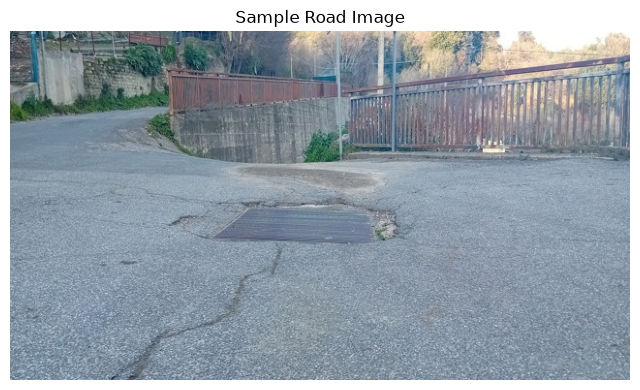

In [124]:
sample_image_file = image_files[0]

sample_image_path = os.path.join(
    IMAGES_DIR,
    sample_image_file
)

image = Image.open(
    sample_image_path
).convert("RGB")

print("Image:", sample_image_file)
print("Image size:", image.size)
print("Image mode:", image.mode)

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Sample Road Image")
plt.show()

##### Create Dataset Folders

In [125]:
for split in ["train", "validation", "test"]:

    for class_name in CLASS_NAMES:

        folder = os.path.join(
            OUTPUT_DIR,
            split,
            class_name
        )

        os.makedirs(
            folder,
            exist_ok=True
        )

print("Dataset folders created.")

Dataset folders created.


##### Read YOLO Class Labels

In [126]:
def get_class(label_path):

    if not os.path.exists(label_path):
        return None

    with open(label_path, "r") as f:

        line = f.readline().strip().split()

    if len(line) == 0:
        return None

    class_id = int(line[0])

    return CLASS_MAP.get(class_id)

##### Shuffle and Split Dataset

In [127]:
random.seed(SEED)

random.shuffle(image_files)

total = len(image_files)

train_end = int(0.70 * total)
val_end = int(0.85 * total)

train_images = image_files[:train_end]

val_images = image_files[
    train_end:val_end
]

test_images = image_files[
    val_end:
]

print("Train:", len(train_images))
print("Validation:", len(val_images))
print("Test:", len(test_images))

Train: 1406
Validation: 301
Test: 302


##### Organize Dataset

In [128]:
def organize_dataset(images, split):

    copied = 0

    for image_file in images:

        label_file = (
            os.path.splitext(image_file)[0]
            + ".txt"
        )

        label_path = os.path.join(
            LABELS_DIR,
            label_file
        )

        class_name = get_class(
            label_path
        )

        if class_name is None:
            continue

        source = os.path.join(
            IMAGES_DIR,
            image_file
        )

        destination = os.path.join(
            OUTPUT_DIR,
            split,
            class_name,
            image_file
        )

        shutil.copy2(
            source,
            destination
        )

        copied += 1

    print(
        split,
        "images copied:",
        copied
    )


organize_dataset(
    train_images,
    "train"
)

organize_dataset(
    val_images,
    "validation"
)

organize_dataset(
    test_images,
    "test"
)

train images copied: 1406
validation images copied: 301
test images copied: 302


##### Create Image Generators

In [129]:
import cv2

def random_blur(image):

    if np.random.random() < 0.20:

        image = cv2.GaussianBlur(
            image.astype(np.float32),
            (3, 3),
            0
        )

    return image


train_datagen = ImageDataGenerator(
    rescale=1./255,
    
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    
    width_shift_range=0.1,
    height_shift_range=0.1,
    
    brightness_range=[0.8, 1.2],
    
    preprocessing_function=random_blur
)


test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [130]:
train_counts = {}

for class_name in CLASS_NAMES:

    folder = os.path.join(
        OUTPUT_DIR,
        "train",
        class_name
    )

    train_counts[class_name] = len(
        os.listdir(folder)
    )


total_samples = sum(train_counts.values())

class_weights = {}

for index, class_name in enumerate(CLASS_NAMES):

    class_count = train_counts[class_name]

    class_weights[index] = (
        total_samples /
        (NUM_CLASSES * class_count)
    )


print("Class Weights:")

for index, weight in class_weights.items():

    print(
        CLASS_NAMES[index],
        "→",
        round(weight, 3)
    )

Class Weights:
Crack → 0.675
Manhole → 1.211
Pothole → 1.442


##### Check Class Distribution

{'Crack': 694, 'Manhole': 387, 'Pothole': 325}


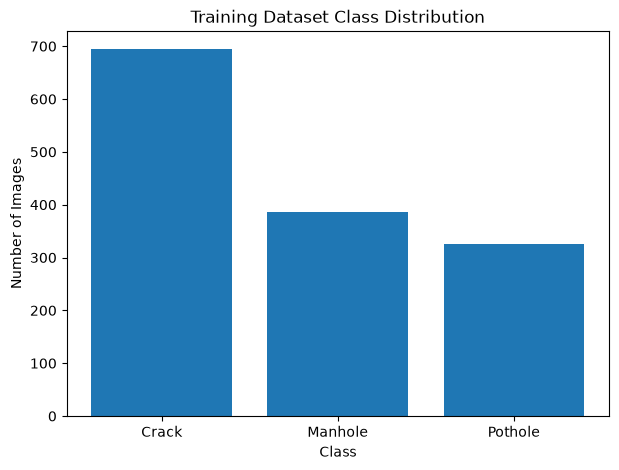

In [131]:
train_counts = {}

for class_name in CLASS_NAMES:

    folder = os.path.join(
        OUTPUT_DIR,
        "train",
        class_name
    )

    train_counts[class_name] = len(
        os.listdir(folder)
    )

print(train_counts)

plt.figure(figsize=(7, 5))

plt.bar(
    train_counts.keys(),
    train_counts.values()
)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Training Dataset Class Distribution")

plt.show()

##### Build Baseline CNN

In [132]:
cnn_model = models.Sequential([

    layers.Input(
        shape=(224, 224, 3)
    ),

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

cnn_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

##### Compile CNN

In [133]:
cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [134]:
print("Class names:")
print(train_ds.class_indices)

print("\nTraining samples:")
print(train_ds.samples)

print("\nValidation samples:")
print(val_ds.samples)

print("\nClass counts:")
print(np.bincount(train_ds.classes))

Class names:
{'Crack': 0, 'Manhole': 1, 'Pothole': 2}

Training samples:
1406

Validation samples:
301

Class counts:
[694 387 325]


##### Train CNNN

In [ ]:
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5


##### Plot CNN Accuracy

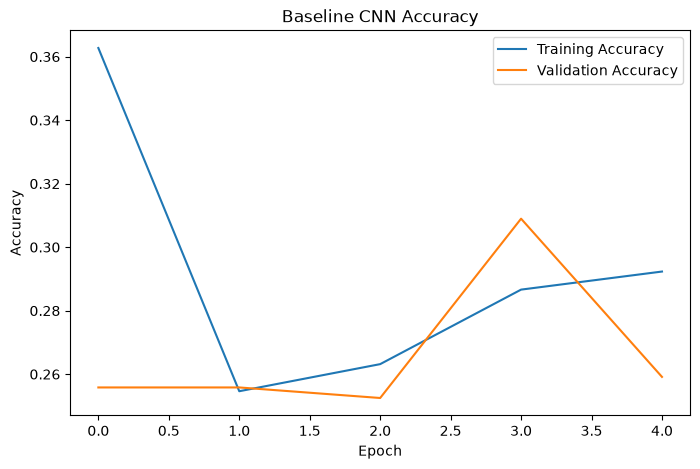

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_cnn.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_cnn.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN Accuracy")

plt.legend()
plt.show()

##### Evaluate CNN

In [ ]:
cnn_test_loss, cnn_test_accuracy = (
    cnn_model.evaluate(
        test_ds,
        verbose=0
    )
)

print(
    "Baseline CNN Test Accuracy:",
    f"{cnn_test_accuracy * 100:.2f}%"
)

Baseline CNN Test Accuracy: 26.16%


##### CNN Predictions

In [ ]:
test_ds.reset()

cnn_predictions = cnn_model.predict(
    test_ds,
    verbose=0
)

cnn_pred_classes = np.argmax(
    cnn_predictions,
    axis=1
)

cnn_true_classes = test_ds.classes

##### CNN Metrics

In [ ]:
cnn_precision = precision_score(
    cnn_true_classes,
    cnn_pred_classes,
    average="weighted",
    zero_division=0
)

cnn_recall = recall_score(
    cnn_true_classes,
    cnn_pred_classes,
    average="weighted",
    zero_division=0
)

cnn_f1 = f1_score(
    cnn_true_classes,
    cnn_pred_classes,
    average="weighted",
    zero_division=0
)

print(
    "CNN Accuracy:",
    f"{cnn_test_accuracy * 100:.2f}%"
)

print(
    "CNN Precision:",
    f"{cnn_precision * 100:.2f}%"
)

print(
    "CNN Recall:",
    f"{cnn_recall * 100:.2f}%"
)

print(
    "CNN F1-score:",
    f"{cnn_f1 * 100:.2f}%"
)

CNN Accuracy: 26.16%
CNN Precision: 59.52%
CNN Recall: 26.16%
CNN F1-score: 11.72%


##### CNN Classification Report

In [ ]:
print(
    classification_report(
        cnn_true_classes,
        cnn_pred_classes,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       Crack       1.00      0.01      0.02       160
     Manhole       0.26      1.00      0.41        77
     Pothole       0.00      0.00      0.00        65

    accuracy                           0.26       302
   macro avg       0.42      0.34      0.14       302
weighted avg       0.60      0.26      0.12       302



##### CNN Confusion Matrix

CNN Confusion Matrix:
[[  2 158   0]
 [  0  77   0]
 [  0  65   0]]


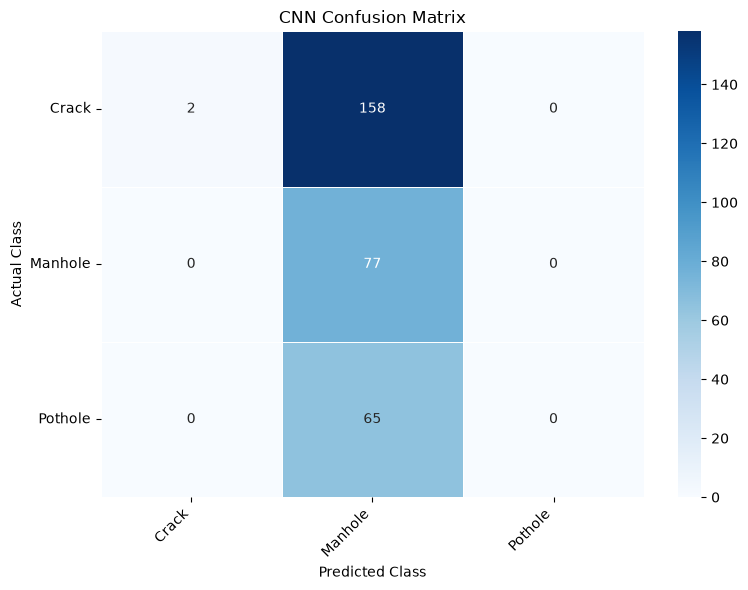

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cnn_cm = confusion_matrix(
    cnn_true_classes,
    cnn_pred_classes
)

# Print confusion matrix values
print("CNN Confusion Matrix:")
print(cnn_cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    cnn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("CNN Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

##### Load MobileNetV2

In [ ]:
mobilenet_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

mobilenet_base.trainable = False

print(
    "MobileNetV2 loaded successfully."
)

MobileNetV2 loaded successfully.


##### Build MobileNetV2

In [ ]:
mobilenet_model = models.Sequential([

    layers.Input(
        shape=(224, 224, 3)
    ),

    mobilenet_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

##### Compile MobileNetV2

In [ ]:
mobilenet_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

##### Train MobileNetV2

In [ ]:
history_mobilenet = (
    mobilenet_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=5,
        class_weight=class_weights
    )
)

Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 35s 710ms/step - accuracy: 0.5725 - loss: 0.9659 - val_accuracy: 0.5515 - val_loss: 0.9363
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 37s 856ms/step - accuracy: 0.5576 - loss: 0.9483 - val_accuracy: 0.5681 - val_loss: 0.9368
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.5797 - loss: 0.9364 - val_accuracy: 0.5781 - val_loss: 0.9278
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.5868 - loss: 0.9319 - val_accuracy: 0.5615 - val_loss: 0.9228
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 36s 814ms/step - accuracy: 0.5818 - loss: 0.9226 - val_accuracy: 0.5681 - val_loss: 0.9235


##### Evaluate MobileNetV2

In [ ]:
mobilenet_loss, mobilenet_accuracy = (
    mobilenet_model.evaluate(
        test_ds,
        verbose=0
    )
)

print(
    
    "MobileNetV2 Test Accuracy:",
    f"{mobilenet_accuracy * 100:.2f}%"
)

MobileNetV2 Test Accuracy: 58.94%


##### MobileNetV2 Metrics

In [ ]:
test_ds.reset()

mobilenet_predictions = (
    mobilenet_model.predict(
        test_ds,
        verbose=0
    )
)

mobilenet_pred_classes = np.argmax(
    mobilenet_predictions,
    axis=1
)

mobilenet_true_classes = test_ds.classes

mobilenet_precision = precision_score(
    mobilenet_true_classes,
    mobilenet_pred_classes,
    average="weighted",
    zero_division=0
)

mobilenet_recall = recall_score(
    mobilenet_true_classes,
    mobilenet_pred_classes,
    average="weighted",
    zero_division=0
)

mobilenet_f1 = f1_score(
    mobilenet_true_classes,
    mobilenet_pred_classes,
    average="weighted",
    zero_division=0
)

print(
    "Accuracy:",
    f"{mobilenet_accuracy * 100:.2f}%"
)

print(
    "Precision:",
    f"{mobilenet_precision * 100:.2f}%"
)

print(
    "Recall:",
    f"{mobilenet_recall * 100:.2f}%"
)

print(
    "F1-score:",
    f"{mobilenet_f1 * 100:.2f}%"
)

Accuracy: 58.94%
Precision: 59.06%
Recall: 58.94%
F1-score: 58.89%


##### MobileNetV2 Classification Report

In [ ]:
print(
    classification_report(
        mobilenet_true_classes,
        mobilenet_pred_classes,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       Crack       0.73      0.76      0.74       160
     Manhole       0.52      0.44      0.48        77
     Pothole       0.32      0.35      0.34        65

    accuracy                           0.59       302
   macro avg       0.53      0.52      0.52       302
weighted avg       0.59      0.59      0.59       302



##### MobileNetV2 Confusion Matrix

MobileNetV2 Confusion Matrix:
[[121  13  26]
 [ 20  34  23]
 [ 24  18  23]]


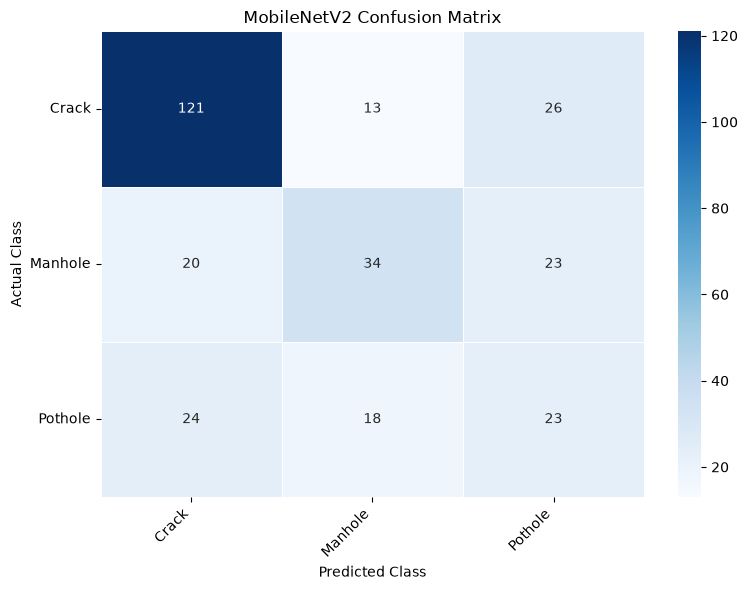

In [ ]:


# Create confusion matrix
mobilenet_cm = confusion_matrix(
    mobilenet_true_classes,
    mobilenet_pred_classes
)

# Print confusion matrix values
print("MobileNetV2 Confusion Matrix:")
print(mobilenet_cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    mobilenet_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("MobileNetV2 Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

##### Load ResNet50

In [ ]:
resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

resnet_base.trainable = False

print(
    "ResNet50 loaded successfully."
)

ResNet50 loaded successfully.


##### Build ResNet50

In [ ]:
resnet_model = models.Sequential([

    layers.Input(
        shape=(224, 224, 3)
    ),

    resnet_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

##### Compile ResNet50

In [ ]:
resnet_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

##### Train ResNet50

In [ ]:
history_resnet = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 152s 3s/step - accuracy: 0.4218 - loss: 1.1496 - val_accuracy: 0.4917 - val_loss: 1.0423
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step - accuracy: 0.4915 - loss: 1.0560 - val_accuracy: 0.4917 - val_loss: 1.0427
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 129s 3s/step - accuracy: 0.4886 - loss: 1.0563 - val_accuracy: 0.4917 - val_loss: 1.0451
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - accuracy: 0.4929 - loss: 1.0489 - val_accuracy: 0.4917 - val_loss: 1.0446
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.4936 - loss: 1.0434 - val_accuracy: 0.4917 - val_loss: 1.0476


##### Evaluate ResNet50

In [ ]:
resnet_loss, resnet_accuracy = (
    resnet_model.evaluate(
        test_ds,
        verbose=0
    )
)

print(
    "ResNet50 Test Accuracy:",
    f"{resnet_accuracy * 100:.2f}%"
)

ResNet50 Test Accuracy: 52.98%


##### ResNet50 Metrics

In [ ]:
# Reset test dataset
test_ds.reset()

# Generate predictions
resnet_predictions = resnet_model.predict(
    test_ds,
    verbose=0
)

# Convert probabilities to predicted class labels
resnet_pred_classes = np.argmax(
    resnet_predictions,
    axis=1
)

# Get actual class labels
resnet_true_classes = test_ds.classes

# Calculate metrics
resnet_accuracy = accuracy_score(
    resnet_true_classes,
    resnet_pred_classes
)

resnet_precision = precision_score(
    resnet_true_classes,
    resnet_pred_classes,
    average="weighted",
    zero_division=0
)

resnet_recall = recall_score(
    resnet_true_classes,
    resnet_pred_classes,
    average="weighted",
    zero_division=0
)

resnet_f1 = f1_score(
    resnet_true_classes,
    resnet_pred_classes,
    average="weighted",
    zero_division=0
)

# Display results
print("ResNet50 Performance Metrics")
print("-" * 35)
print(f"Accuracy : {resnet_accuracy * 100:.2f}%")
print(f"Precision: {resnet_precision * 100:.2f}%")
print(f"Recall   : {resnet_recall * 100:.2f}%")
print(f"F1-score : {resnet_f1 * 100:.2f}%")

ResNet50 Performance Metrics
-----------------------------------
Accuracy : 52.98%
Precision: 28.07%
Recall   : 52.98%
F1-score : 36.70%


##### ResNet50 Report + Confusion Matrix

ResNet50 Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

       Crack       0.53      1.00      0.69       160
     Manhole       0.00      0.00      0.00        77
     Pothole       0.00      0.00      0.00        65

    accuracy                           0.53       302
   macro avg       0.18      0.33      0.23       302
weighted avg       0.28      0.53      0.37       302

ResNet50 Confusion Matrix:
[[160   0   0]
 [ 77   0   0]
 [ 65   0   0]]


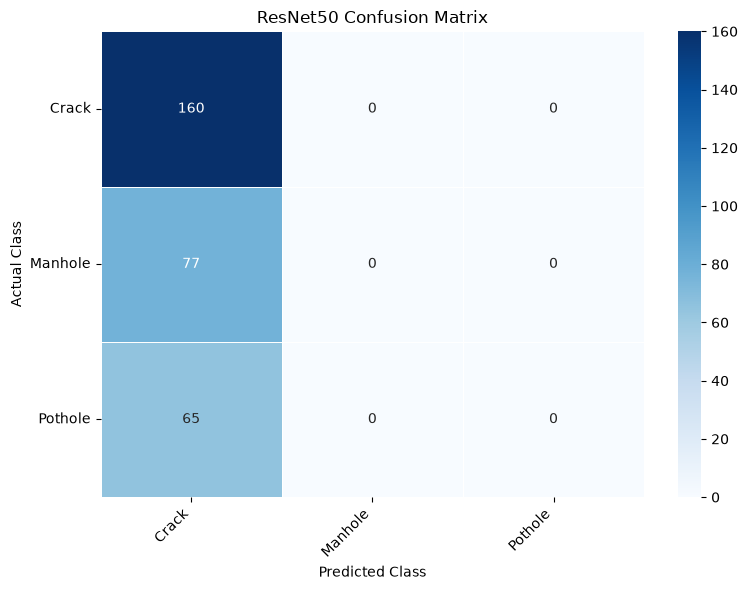

In [ ]:
# Classification Report
print("ResNet50 Classification Report")
print("-" * 50)

print(
    classification_report(
        resnet_true_classes,
        resnet_pred_classes,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

# Create confusion matrix
resnet_cm = confusion_matrix(
    resnet_true_classes,
    resnet_pred_classes
)

# Print confusion matrix values
print("ResNet50 Confusion Matrix:")
print(resnet_cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    resnet_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("ResNet50 Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

##### Load EfficientNetB0

In [ ]:
efficientnet_base = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

efficientnet_base.trainable = False

print(
    "EfficientNetB0 loaded successfully."
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
EfficientNetB0 loaded successfully.


##### Build EfficientNetB0

In [ ]:
efficientnet_model = models.Sequential([

    layers.Input(
        shape=(224, 224, 3)
    ),

    efficientnet_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

##### Compile EfficientNetB0

In [ ]:
efficientnet_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

##### Train EfficientNetB0

In [ ]:
history_efficientnet = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 49s 900ms/step - accuracy: 0.4538 - loss: 1.0866 - val_accuracy: 0.4917 - val_loss: 1.0569
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.4922 - loss: 1.0582 - val_accuracy: 0.4917 - val_loss: 1.0556
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 36s 810ms/step - accuracy: 0.4908 - loss: 1.0522 - val_accuracy: 0.4917 - val_loss: 1.0479
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.4929 - loss: 1.0525 - val_accuracy: 0.4917 - val_loss: 1.0474
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.4936 - loss: 1.0497 - val_accuracy: 0.4917 - val_loss: 1.0487


##### Evalution EfficientNetBO

In [ ]:
efficientnet_loss, efficientnet_accuracy = (
    efficientnet_model.evaluate(
        test_ds,
        verbose=0
    )
)

print(
    "EfficientNetB0 Test Accuracy:",
    f"{efficientnet_accuracy * 100:.2f}%"
)

EfficientNetB0 Test Accuracy: 52.98%


##### EfficientNet Metrics

In [ ]:


# Reset test dataset
test_ds.reset()

# Generate predictions
efficientnet_predictions = efficientnet_model.predict(
    test_ds,
    verbose=0
)

# Convert probabilities to predicted class labels
efficientnet_pred_classes = np.argmax(
    efficientnet_predictions,
    axis=1
)

# Get actual class labels
efficientnet_true_classes = test_ds.classes

# Calculate performance metrics
efficientnet_accuracy = accuracy_score(
    efficientnet_true_classes,
    efficientnet_pred_classes
)

efficientnet_precision = precision_score(
    efficientnet_true_classes,
    efficientnet_pred_classes,
    average="weighted",
    zero_division=0
)

efficientnet_recall = recall_score(
    efficientnet_true_classes,
    efficientnet_pred_classes,
    average="weighted",
    zero_division=0
)

efficientnet_f1 = f1_score(
    efficientnet_true_classes,
    efficientnet_pred_classes,
    average="weighted",
    zero_division=0
)

# Display results
print("EfficientNet Performance Metrics")
print("-" * 40)
print(f"Accuracy : {efficientnet_accuracy * 100:.2f}%")
print(f"Precision: {efficientnet_precision * 100:.2f}%")
print(f"Recall   : {efficientnet_recall * 100:.2f}%")
print(f"F1-score : {efficientnet_f1 * 100:.2f}%")

EfficientNet Performance Metrics
----------------------------------------
Accuracy : 52.98%
Precision: 28.07%
Recall   : 52.98%
F1-score : 36.70%


##### EfficientNet Report + Confusion Matrix

EfficientNetB0 Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

       Crack       0.53      1.00      0.69       160
     Manhole       0.00      0.00      0.00        77
     Pothole       0.00      0.00      0.00        65

    accuracy                           0.53       302
   macro avg       0.18      0.33      0.23       302
weighted avg       0.28      0.53      0.37       302

EfficientNetB0 Confusion Matrix:
[[160   0   0]
 [ 77   0   0]
 [ 65   0   0]]


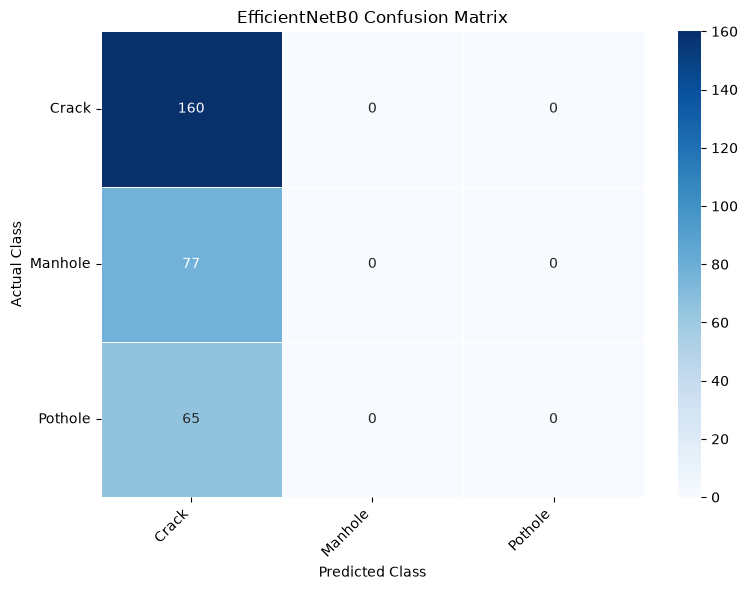

In [ ]:

# Classification Report
print("EfficientNetB0 Classification Report")
print("-" * 50)

print(
    classification_report(
        efficientnet_true_classes,
        efficientnet_pred_classes,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

# Create confusion matrix
efficientnet_cm = confusion_matrix(
    efficientnet_true_classes,
    efficientnet_pred_classes
)

# Print confusion matrix values
print("EfficientNetB0 Confusion Matrix:")
print(efficientnet_cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    efficientnet_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("EfficientNetB0 Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

##### Compare All Models

In [ ]:
import pandas as pd

# Create model performance comparison table
results = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "MobileNetV2",
        "ResNet50",
        "EfficientNetB0"
    ],

    "Accuracy": [
        cnn_test_accuracy,
        mobilenet_accuracy,
        resnet_accuracy,
        efficientnet_accuracy
    ],

    "Precision": [
        cnn_precision,
        mobilenet_precision,
        resnet_precision,
        efficientnet_precision
    ],

    "Recall": [
        cnn_recall,
        mobilenet_recall,
        resnet_recall,
        efficientnet_recall
    ],

    "F1_Score": [
        cnn_f1,
        mobilenet_f1,
        resnet_f1,
        efficientnet_f1
    ]
})

# Convert metrics from decimal to percentage
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score"
]

results[metric_columns] = results[metric_columns] * 100

# Round values to 2 decimal places
results = results.round(2)

# Display results
results

,Model,Accuracy,Precision,Recall,F1_Score
0,Baseline CNN,54.97,72.60,54.97,41.35
1,MobileNetV2,57.95,56.45,57.95,56.91
2,ResNet50,52.98,28.07,52.98,36.70
3,EfficientNetB0,52.98,28.07,52.98,36.70


##### Model Comparison Chart

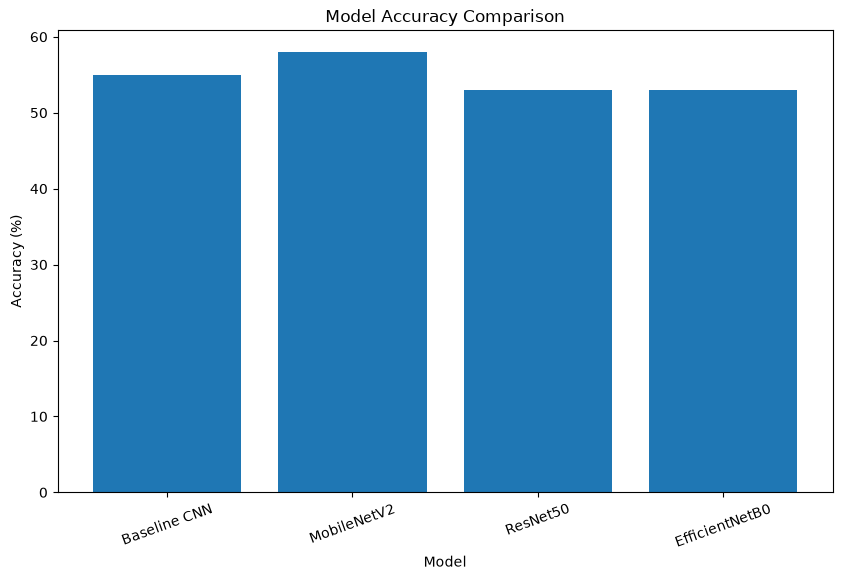

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")

plt.xticks(rotation=20)

plt.show()

##### Select Best Model

In [ ]:
best_model_name = results.loc[
    results["Accuracy"].idxmax(),
    "Model"
]

best_accuracy = results["Accuracy"].max()

print(
    "Best Model:",
    best_model_name
)

print(
    "Best Accuracy:",
    f"{best_accuracy:.2f}%"
)

Best Model: MobileNetV2
Best Accuracy: 57.95%


##### Select Model Object

In [ ]:
model_objects = {

    "Baseline CNN": cnn_model,

    "MobileNetV2": mobilenet_model,

    "ResNet50": resnet_model,

    "EfficientNetB0": efficientnet_model
}

best_model = model_objects[
    best_model_name
]

print(
    "Selected model:",
    best_model_name
)

Selected model: MobileNetV2


##### Fine-Tuning Best Model

In [ ]:
if best_model_name == "MobileNetV2":

    base_model = mobilenet_base

elif best_model_name == "ResNet50":

    base_model = resnet_base

elif best_model_name == "EfficientNetB0":

    base_model = efficientnet_base

else:

    base_model = None


if base_model is not None:

    base_model.trainable = True

    for layer in base_model.layers[:-20]:

        layer.trainable = False

    print(
        "Last 20 layers are trainable."
    )

else:

    print(
        "Baseline CNN selected."
    )

Last 20 layers are trainable.


##### Recompile Fine-Tuned Model

In [ ]:
if base_model is not None:

    best_model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.00001
        ),

        loss="categorical_crossentropy",

        metrics=["accuracy"]
    )

    print(
        "Model recompiled for fine-tuning."
    )

Model recompiled for fine-tuning.


##### Fine-Tune

In [ ]:
history_finetune = best_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    class_weight=class_weights
)
print(
        "Fine-tuning completed."
    )

Epoch 1/3
44/44 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.4751 - loss: 1.0089 - val_accuracy: 0.5449 - val_loss: 0.9397
Epoch 2/3
44/44 ━━━━━━━━━━━━━━━━━━━━ 42s 946ms/step - accuracy: 0.5164 - loss: 0.9657 - val_accuracy: 0.5382 - val_loss: 0.9342
Epoch 3/3
44/44 ━━━━━━━━━━━━━━━━━━━━ 37s 840ms/step - accuracy: 0.5292 - loss: 0.9385 - val_accuracy: 0.5515 - val_loss: 0.9352
Fine-tuning completed.


##### Evaluate Fine-Tuned Model

In [ ]:
fine_loss, fine_accuracy = (
    best_model.evaluate(
        test_ds,
        verbose=0
    )
)

print(
    "Fine-Tuned Test Accuracy:",
    f"{fine_accuracy * 100:.2f}%"
)

Fine-Tuned Test Accuracy: 58.94%


##### Fine-Tuned Metrics

In [ ]:

# Reset test dataset
test_ds.reset()

# Generate predictions
fine_predictions = best_model.predict(
    test_ds,
    verbose=0
)

# Convert probabilities to predicted class labels
fine_pred_classes = np.argmax(
    fine_predictions,
    axis=1
)

# Get actual class labels
fine_true_classes = test_ds.classes

# Calculate performance metrics
fine_accuracy = accuracy_score(
    fine_true_classes,
    fine_pred_classes
)

fine_precision = precision_score(
    fine_true_classes,
    fine_pred_classes,
    average="weighted",
    zero_division=0
)

fine_recall = recall_score(
    fine_true_classes,
    fine_pred_classes,
    average="weighted",
    zero_division=0
)

fine_f1 = f1_score(
    fine_true_classes,
    fine_pred_classes,
    average="weighted",
    zero_division=0
)

# Display results
print("Fine-Tuned Best Model Performance")
print("-" * 45)
print(f"Accuracy : {fine_accuracy * 100:.2f}%")
print(f"Precision: {fine_precision * 100:.2f}%")
print(f"Recall   : {fine_recall * 100:.2f}%")
print(f"F1-score : {fine_f1 * 100:.2f}%")

Fine-Tuned Best Model Performance
---------------------------------------------
Accuracy : 58.94%
Precision: 56.71%
Recall   : 58.94%
F1-score : 57.39%


##### Fine-Tuned Classification Report

In [ ]:
print(
    classification_report(
        fine_true_classes,
        fine_pred_classes,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       Crack       0.72      0.77      0.75       160
     Manhole       0.47      0.56      0.51        77
     Pothole       0.30      0.18      0.23        65

    accuracy                           0.59       302
   macro avg       0.50      0.50      0.49       302
weighted avg       0.57      0.59      0.57       302



##### Fine-Tuned Confusion Matrix

Fine-Tuned Model Confusion Matrix:
[[123  22  15]
 [ 21  43  13]
 [ 26  27  12]]


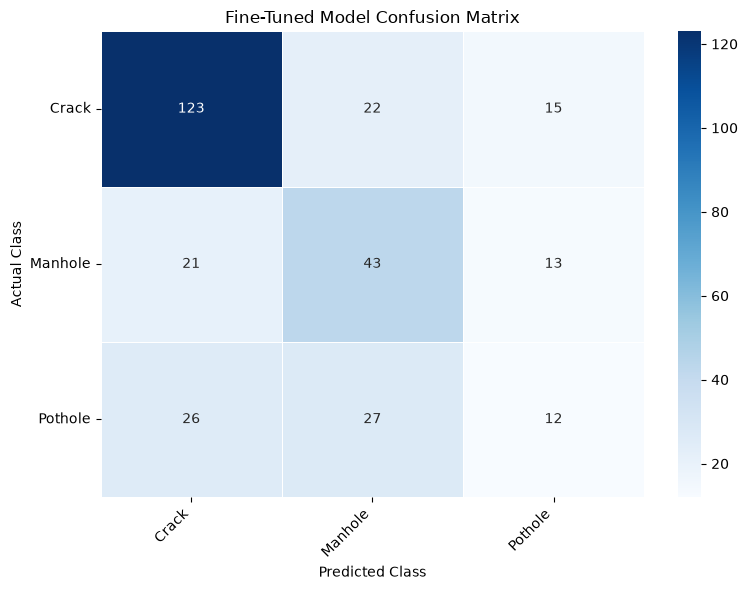

In [ ]:


# Create confusion matrix
fine_cm = confusion_matrix(
    fine_true_classes,
    fine_pred_classes
)

# Print confusion matrix values
print("Fine-Tuned Model Confusion Matrix:")
print(fine_cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    fine_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Fine-Tuned Model Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

##### Check Fine-Tuning Improvement

In [ ]:
print(
    "Before Fine-Tuning:",
    f"{best_accuracy:.2f}%"
)

print(
    "After Fine-Tuning:",
    f"{fine_accuracy * 100:.2f}%"
)

improvement = (
    fine_accuracy * 100
) - best_accuracy

print(
    "Improvement:",
    f"{improvement:.2f} percentage points"
)

Before Fine-Tuning: 57.95%
After Fine-Tuning: 58.94%
Improvement: 0.99 percentage points


##### Save Final Model

In [ ]:
FINAL_MODEL_PATH = os.path.join(
    PROJECT_DIR,
    "road_damage_final.keras"
)

best_model.save(
    FINAL_MODEL_PATH
)

print(
    "Final model saved successfully!"
)

print(
    "Path:",
    FINAL_MODEL_PATH
)

Final model saved successfully!
Path: C:\Users\Devendra\Automated Road Damage Classification\road_damage_final.keras


##### Create Single Image Prediction Function

In [ ]:
def predict_road_damage(
    image_path,
    model=best_model
):

    image = Image.open(
        image_path
    ).convert("RGB")

    image = image.resize(
        IMG_SIZE
    )

    image_array = (
        np.array(image) / 255.0
    )

    input_image = np.expand_dims(
        image_array,
        axis=0
    )

    predictions = model.predict(
        input_image,
        verbose=0
    )

    predicted_index = np.argmax(
        predictions[0]
    )

    predicted_class = CLASS_NAMES[
        predicted_index
    ]

    confidence = (
        predictions[0][predicted_index]
        * 100
    )

    return (
        predicted_class,
        confidence,
        predictions[0]
    )

##### Test Single Image

Prediction: Crack
Confidence: 73.55%
Probabilities: [0.73551404 0.14940432 0.1150817 ]


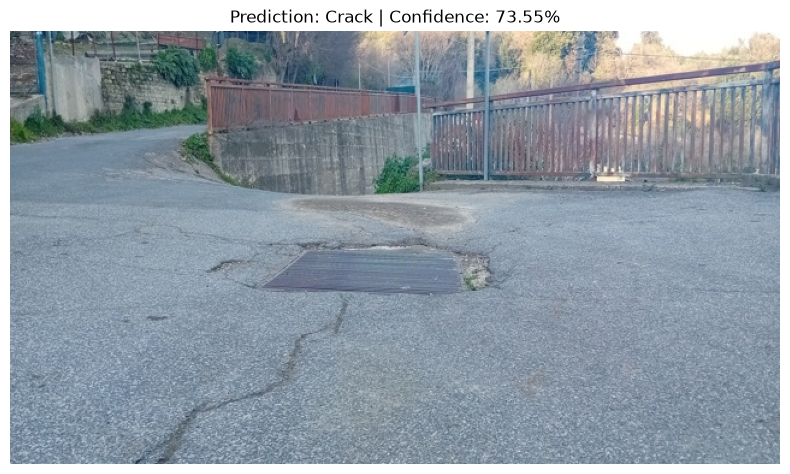

In [ ]:
# Predict road damage
predicted_class, confidence, probabilities = predict_road_damage(
    sample_image_path
)

# Print prediction results
print("Prediction:", predicted_class)
print("Confidence:", f"{confidence:.2f}%")
print("Probabilities:", probabilities)

# Load and display image
image = Image.open(
    sample_image_path
).convert("RGB")

plt.figure(figsize=(8, 6))

plt.imshow(image)

plt.axis("off")

plt.title(
    f"Prediction: {predicted_class} | "
    f"Confidence: {confidence:.2f}%"
)

plt.tight_layout()
plt.show()

##### Damage Recommendation

In [ ]:
RECOMMENDATIONS = {

    "Pothole":
        "Schedule immediate road repair and inspect the affected area.",

    "Crack":
        "Inspect the crack and apply appropriate sealing or surface repair.",

    "Manhole":
        "Inspect and secure the manhole area to ensure road-user safety."
}

recommendation = RECOMMENDATIONS[
    predicted_class
]

print(
    "Detected:",
    predicted_class
)

print(
    "Recommended Action:",
    recommendation
)

Detected: Crack
Recommended Action: Inspect the crack and apply appropriate sealing or surface repair.


##### Measure Prediction Latency

In [ ]:
start_time = time.time()

predicted_class, confidence, probabilities = (
    predict_road_damage(
        sample_image_path
    )
)

end_time = time.time()

prediction_time = (
    end_time - start_time
)

print(
    "Prediction:",
    predicted_class
)

print(
    "Confidence:",
    f"{confidence:.2f}%"
)

print(
    "Prediction Latency:",
    f"{prediction_time:.4f} seconds"
)


Prediction: Crack
Confidence: 73.55%
Prediction Latency: 0.3096 seconds


##### Find Last Convolutional Layer for Grad-CAM

In [ ]:

base_model = None
base_index = None

for i, layer in enumerate(best_model.layers):
    if isinstance(layer, tf.keras.Model):
        base_model = layer
        base_index = i
        break

print("Best Model:", best_model_name)

if base_model is not None:
    print("Base Model:", base_model.name)
    print("Base Model Index:", base_index)

    last_conv_layer = None

    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer = layer

    if last_conv_layer is not None:
        print("Last Conv Layer:", last_conv_layer.name)
    else:
        print("No Conv2D layer found.")
else:
    print("No nested base model found.")

Best Model: MobileNetV2
Base Model: mobilenetv2_1.00_224
Base Model Index: 0
Last Conv Layer: Conv_1


##### Grad-CAM Function

In [ ]:


def make_gradcam(image_path, model, base_model, base_index, last_conv_layer):

    # Load image
    image = Image.open(image_path).convert("RGB")
    original_image = image.copy()

    # Resize
    image = image.resize(IMG_SIZE)

    # Convert to array
    image_array = np.array(image).astype("float32") / 255.0

    # Add batch dimension
    input_image = np.expand_dims(image_array, axis=0)

    # Create Grad-CAM model for the base model
    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[
            last_conv_layer.output,
            base_model.output
        ]
    )

    # Calculate gradients
    with tf.GradientTape() as tape:

        conv_output, base_output = grad_model(input_image)

        x = base_output

        # Pass through the remaining classification layers
        for layer in model.layers[base_index + 1:]:
            x = layer(x)

        predictions = x

        predicted_index = tf.argmax(predictions[0])

        class_score = predictions[0, predicted_index]

    # Gradients
    gradients = tape.gradient(
        class_score,
        conv_output
    )

    # Average gradients
    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    conv_output = conv_output[0]

    # Weight feature maps
    heatmap = conv_output @ pooled_gradients[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    # ReLU
    heatmap = tf.maximum(heatmap, 0)

    # Normalize
    heatmap = heatmap / (
        tf.reduce_max(heatmap) + 1e-8
    )

    return (
        original_image,
        heatmap.numpy(),
        predicted_index.numpy(),
        predictions.numpy()[0]
    )

##### Generate Grad-CAM

In [ ]:


gradcam_result = make_gradcam(
    sample_image_path,
    best_model,
    base_model,
    base_index,
    last_conv_layer
)

original_image = gradcam_result[0]

heatmap = gradcam_result[1]

predicted_index = gradcam_result[2]

prediction_scores = gradcam_result[3]

predicted_name = CLASS_NAMES[predicted_index]

confidence = prediction_scores[predicted_index] * 100

print("Predicted Class:", predicted_name)
print("Confidence:", round(confidence, 2), "%")
print("Heatmap Shape:", heatmap.shape)

Predicted Class: Crack
Confidence: 73.55 %
Heatmap Shape: (7, 7)


##### Display Grad-CAM

Grad-CAM Analysis
----------------------------------------
Predicted Class: Crack
Confidence: 73.55%


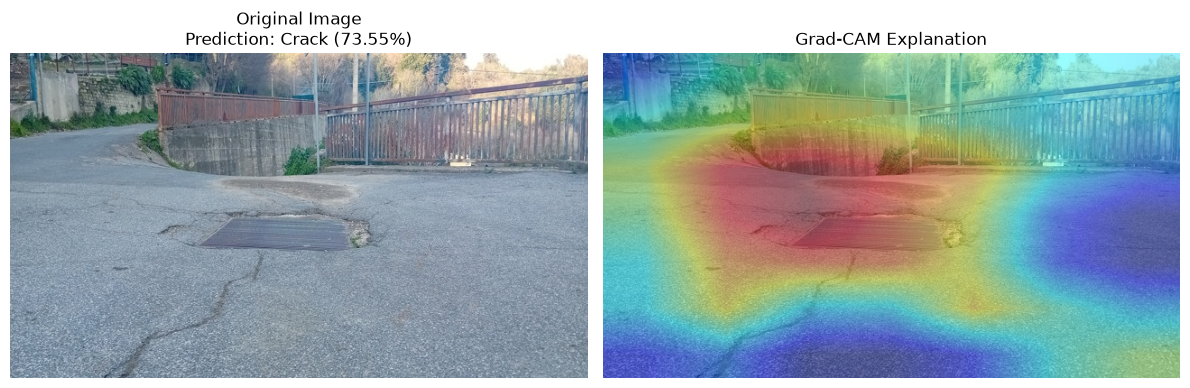

In [ ]:


import cv2


# Resize heatmap to original image size
heatmap_resized = cv2.resize(
    heatmap,
    (original_image.width, original_image.height)
)

# Convert heatmap to 8-bit format
heatmap_uint8 = np.uint8(
    255 * heatmap_resized
)

# Apply color map
heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

# Convert BGR to RGB
heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

# Convert original image to NumPy array
original_array = np.array(
    original_image
)

# Create Grad-CAM overlay
overlay = cv2.addWeighted(
    original_array,
    0.6,
    heatmap_color,
    0.4,
    0
)

# Print prediction details
print("Grad-CAM Analysis")
print("-" * 40)
print("Predicted Class:", predicted_name)
print("Confidence:", f"{confidence:.2f}%")

# Display original image and Grad-CAM
plt.figure(figsize=(12, 5))

# Original image
plt.subplot(1, 2, 1)

plt.imshow(original_image)

plt.axis("off")

plt.title(
    f"Original Image\n"
    f"Prediction: {predicted_name} "
    f"({confidence:.2f}%)"
)

# Grad-CAM overlay
plt.subplot(1, 2, 2)

plt.imshow(overlay)

plt.axis("off")

plt.title(
    "Grad-CAM Explanation"
)

plt.tight_layout()
plt.show()

##### Final Project Summary

In [ ]:
print("=" * 60)
print("FINAL PROJECT SUMMARY")
print("=" * 60)

print(
    "Baseline CNN Accuracy:",
    f"{cnn_test_accuracy * 100:.2f}%"
)

print(
    "MobileNetV2 Accuracy:",
    f"{mobilenet_accuracy * 100:.2f}%"
)

print(
    "ResNet50 Accuracy:",
    f"{resnet_accuracy * 100:.2f}%"
)

print(
    "EfficientNetB0 Accuracy:",
    f"{efficientnet_accuracy * 100:.2f}%"
)

print(
    "Best Model:",
    best_model_name
)

print(
    "Best Initial Accuracy:",
    f"{best_accuracy:.2f}%"
)

print(
    "Fine-Tuned Accuracy:",
    f"{fine_accuracy * 100:.2f}%"
)

print(
    "Final Precision:",
    f"{fine_precision * 100:.2f}%"
)

print(
    "Final Recall:",
    f"{fine_recall * 100:.2f}%"
)

print(
    "Final F1-score:",
    f"{fine_f1 * 100:.2f}%"
)

print(
    "Prediction Latency:",
    f"{prediction_time:.4f} seconds"
)

print("=" * 60)

FINAL PROJECT SUMMARY
Baseline CNN Accuracy: 26.16%
MobileNetV2 Accuracy: 58.94%
ResNet50 Accuracy: 52.98%
EfficientNetB0 Accuracy: 52.98%
Best Model: MobileNetV2
Best Initial Accuracy: 57.95%
Fine-Tuned Accuracy: 58.94%
Final Precision: 56.71%
Final Recall: 58.94%
Final F1-score: 57.39%
Prediction Latency: 0.3096 seconds
